# 11 · The same list, re-run at n > 1

Notebook 10 actioned `PUBLISHABILITY.md`'s watch-list and closed eight of ten items.
Every one of them landed at **n = 1**: one replication, one split, one corrected family,
one significance rule nobody checked.

This notebook is what happened when each was re-run properly. Notebook 10 asked *is the
effect there?* This asks *how big is it, how sure are we, and does it move when the
mechanism says it should* — and that question changes two answers.

**Three claims made earlier in this repository do not survive**, including one in
notebook 10. All three are corrected at source; `PUBLISHING.md` carries the full write-up.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

## 1. Coverage bias — from "it replicates" to "this is what causes it"

Notebook 10 showed the effect survives on a disjoint pool. That rules out one
alternative: that it belonged to those particular thirteen models. It leaves the boring
one standing — maybe training on **more** items is simply worse, and coverage has nothing
to do with it. The union arm differs from the dense arm in two ways at once.

Start with pools that differ in how uneven their coverage is.

In [2]:
d = load("chutes/20_dose_response")
dr = d["dose_response"]
display(table([
    {"pools": "control — all columns graded on the same tasks",
     "n": dr["controls"]["n"],
     "union arm trains on": f"{dr['controls']['mean_union_over_dense_train']:.2f}x",
     "mean gap": pct(dr["controls"]["mean_gap"]),
     "largest |gap|": pct(dr["controls"]["max_abs_gap"])},
    {"pools": "mixed coverage", "n": dr["asymmetric"]["n"],
     "union arm trains on": "~10x",
     "mean gap": pct(dr["asymmetric"]["mean_gap"]),
     "largest |gap|": f"positive in {dr['asymmetric']['replicated_in']} of {dr['asymmetric']['n']}"},
]))
md(dr["reading"])

,pools,n,union arm trains on,mean gap,largest |gap|
0,control — all columns graded on the same tasks,4,1.07x,-0.1%,0.3%
1,mixed coverage,15,~10x,13.6%,positive in 15 of 15


Across 19 pools the gap tracks coverage asymmetry with r = +0.89 (slope +0.166 per unit of asymmetry). In the 4 control pools — columns graded on the same task mix, but the union arm still trained on 1.07× the items — the mean gap is -0.1% and the largest in absolute value is 0.3%. In the 15 asymmetric pools it is +13.6%, positive in 15 of 15. Holding the amount of training data fixed and varying only the coverage, the gap is +16.5% — larger than with ten times the data, positive in 15 of 15. So more data is not the cause; it is a partial compensation for the damage that uneven coverage does.

The controls are the point: they **still** have a union arm training on more items than
their dense arm, so "more data is worse" predicts an effect there and there is none.

But that is a two-level contrast, not a dose. Real pools sit at either ~0.0 or ~0.85
asymmetry and nothing between — one narrowly graded column is enough to collapse the
intersection. Two more experiments separate quantity from coverage properly.

### 1a. Hold the item count fixed

Train the union arm on a random subset of the union items of **exactly the dense arm's
size**. Only the coverage differs.

In [3]:
fr = d["first_replication"]
display(table([
    {"arm": "dense core", "train items": fr["dense_best"]["train_items"],
     "fully observed": pct(fr["dense_best"]["dense_share_of_train"]),
     "quality retained": pct(fr["dense_best"]["quality_vs_frontier"])},
    {"arm": "union", "train items": fr["union_best"]["train_items"],
     "fully observed": pct(fr["union_best"]["dense_share_of_train"]),
     "quality retained": pct(fr["union_best"]["quality_vs_frontier"])},
    {"arm": "union, size-matched", "train items": fr["union_matched_n_best"]["train_items"],
     "fully observed": pct(fr["union_matched_n_best"]["dense_share_of_train"]),
     "quality retained": pct(fr["union_matched_n_best"]["quality_vs_frontier"])},
]))
finding("correction",
        f"The gap is {pct(fr['gap_at_matched_n'])} at equal n against "
        f"{pct(fr['gap_points'])} with ten times the data. More data is not the cause — "
        f"it is a partial compensation, buying back about a fifth of what uneven "
        f"coverage costs. 'Ten times the data costs twelve points' was conflating two "
        f"effects with opposite signs.")

,arm,train items,fully observed,quality retained
0,dense core,2548,100.0%,103.3%
1,union,23663,10.8%,84.2%
2,"union, size-matched",2548,10.9%,79.5%


> **CORRECTION** — The gap is 23.7% at equal n against 19.1% with ten times the data. More data is not the cause — it is a partial compensation, buying back about a fifth of what uneven coverage costs. 'Ten times the data costs twelve points' was conflating two effects with opposite signs.

### 1b. Manipulate nothing but the mask

Thirteen columns all graded on the same 22 tasks — coverage uniform, effect absent — then
remove whole tasks from six of them. Same models, same items, same prices, same code
path. Whole tasks rather than random cells, because that is the shape real unevenness
has, and because random removal would make the missingness independent of the features,
which is the assumption under which the bias vanishes.

In [4]:
ms = d["mask_sweep"]
display(table([{"removed": pct(r["target_fraction_removed"], 0),
                "realised asymmetry": round(r["coverage_asymmetry"], 3),
                "dense core": r["dense_core_items"],
                "gap, size-matched": pct(r["gap_at_matched_n"]),
                "gap, union keeps all": pct(r["gap_points"])} for r in ms["rows"]]))
md(ms["reading"])

,removed,realised asymmetry,dense core,"gap, size-matched","gap, union keeps all"
0,0%,0.0000,15478,0.0%,-0.0%
1,10%,0.4630,8321,1.6%,2.3%
2,20%,0.8180,2815,6.1%,2.7%
3,35%,0.9050,1463,7.9%,2.3%
4,50%,0.9220,1210,10.9%,3.5%


Thirteen columns that were all graded on the same tasks, with coverage progressively removed from 6 of them. At zero removal the gap is +0.0%; at 50% removal it is +10.9% with the training-set size held at the dense arm's, and +3.5% with the union arm keeping every item it has. Across the sweep the size-matched gap tracks the realised asymmetry at r = +0.91. Nothing varies here except which cells are observed — same models, same items, same prices — so the effect is caused by the coverage and not by anything about the pool. 2 of 7 levels are not reported: past 65% removal the dense core falls below 300 items and the comparison stops being between two trained routers.

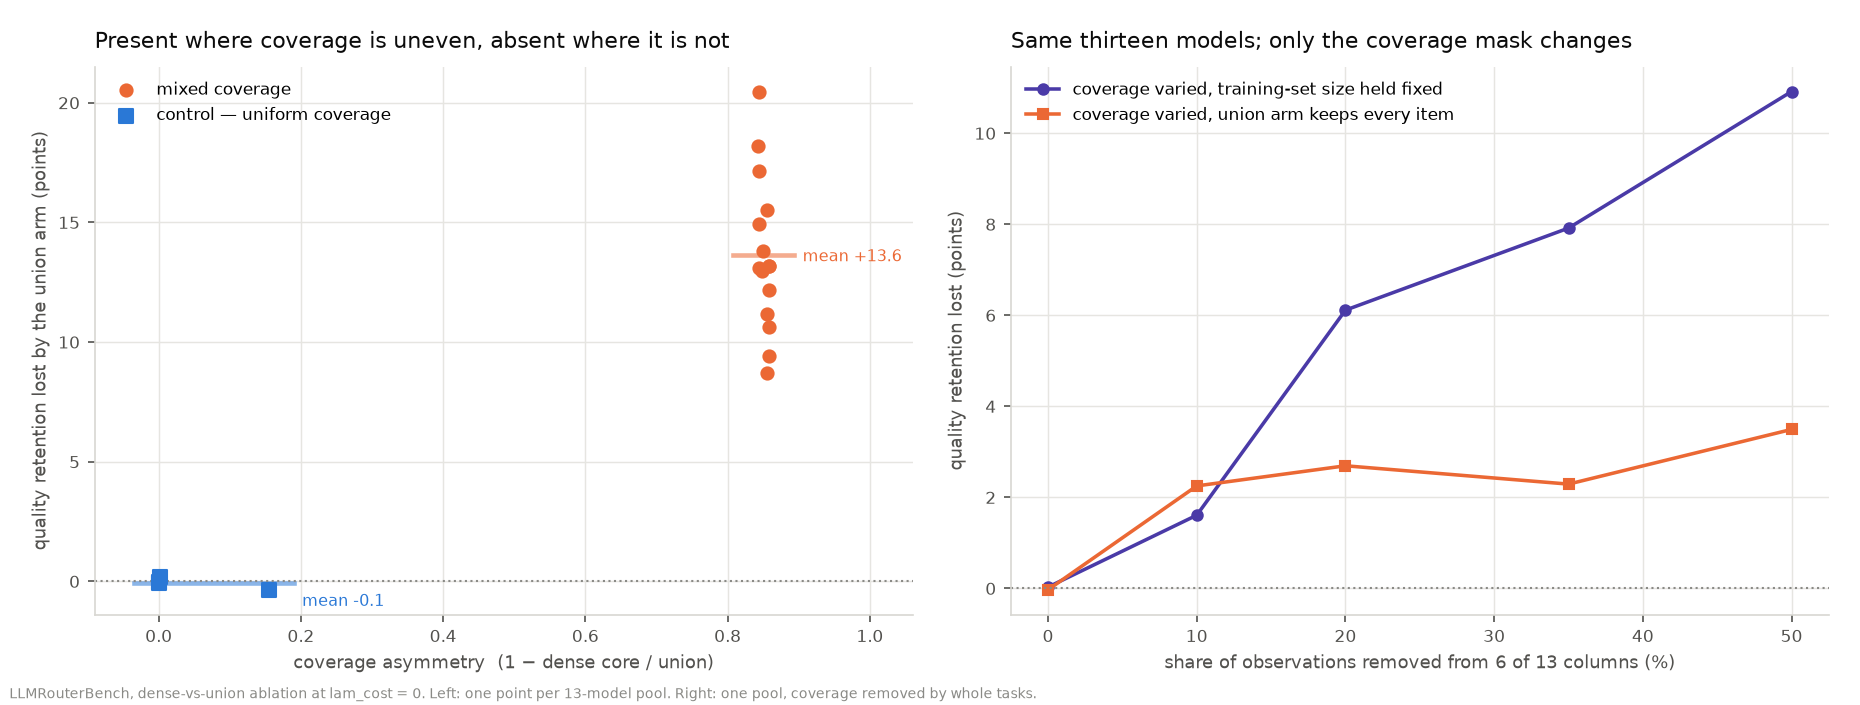

*Left: one point per 13-model pool, against how uneven its coverage is; squares are the uniform-coverage controls. Right: one pool, coverage removed by whole tasks — the purple line holds the training-set size fixed, so only coverage varies.*

> **SUPPORTED** — Over 5 splits the gap is +19.4% ± 0.6% (sd), positive in 5 of 5. Present where the asymmetry is, absent where it is not, unchanged when the data volume is held fixed, monotone in a dose that varies nothing else, and stable across splits. That is a causal claim.

In [5]:
show("chutes_12_coverage_cause",
     "Left: one point per 13-model pool, against how uneven its coverage is; squares are "
     "the uniform-coverage controls. Right: one pool, coverage removed by whole tasks — "
     "the purple line holds the training-set size fixed, so only coverage varies.")
st = d["seed_stability"]
finding("supported", st["reading"] + " Present where the asymmetry is, absent where it is "
        "not, unchanged when the data volume is held fixed, monotone in a dose that "
        "varies nothing else, and stable across splits. That is a causal claim.")

## 2. Error bars, on two instruments that answer different questions

`PUBLISHABILITY.md` §6 asked for k-fold; notebook 10 answered with a bootstrap. They are
not interchangeable:

- the **bootstrap** holds the fitted router fixed and resamples evaluation items — *how
  precisely do we know what this policy does on questions like these*;
- **k-fold** refits on each of k disjoint training sets — *how much does the policy move
  when its training data changes*.

Here every dense item is held out exactly once, which also yields a pooled out-of-fold
estimate over the whole core.

In [6]:
kf = load("chutes/21_kfold")
display(table([{"k": k, "trains on": pct(kf["by_k"][str(k)]["train_frac"], 0),
                "savings vs best single": pct(kf["by_k"][str(k)]["savings_vs_best_single"]["mean"]),
                "fold sd": pct(kf["by_k"][str(k)]["savings_vs_best_single"]["sd"]),
                "quality vs best single": pct(kf["by_k"][str(k)]["quality_vs_best_single"]["mean"]),
                "pooled out-of-fold": pct(kf["by_k"][str(k)]["pooled_out_of_fold"]["savings_vs_best_single"])}
               for k in kf["ks"]]))
b = load("chutes/16_bootstrap")["savings_vs_best_single"]
md(f"The bootstrap, for comparison: **{pct(b['mean'])}** "
   f"(95% CI {pct(b['lo'])}–{pct(b['hi'])}). The level is not in doubt.")

,k,trains on,savings vs best single,fold sd,quality vs best single,pooled out-of-fold
0,3,67%,23.0%,3.0%,99.3%,23.0%
1,5,80%,21.9%,2.2%,98.9%,21.9%
2,10,90%,21.4%,3.3%,99.5%,21.4%


The bootstrap, for comparison: **20.2%** (95% CI 15.8%–24.6%). The level is not in doubt.

What *is* in doubt is a conclusion. Notebook 10 read the bootstrap's quality interval
containing 1.0 as support for "we match the best single model". The k-fold interval
answers that question differently at different k.

In [7]:
par = kf["does_the_quality_interval_contain_parity"]
qb = load("chutes/16_bootstrap")["quality_vs_best_single"]
rows = [{"instrument": "bootstrap over items", "quality": pct(qb["mean"], 2),
         "95% interval": f"[{pct(qb['lo'], 2)}, {pct(qb['hi'], 2)}]",
         "contains parity": "yes" if par["bootstrap"] else "no"}]
for k in kf["ks"]:
    q = kf["by_k"][str(k)]["quality_vs_best_single"]
    rows.append({"instrument": f"{k}-fold", "quality": pct(q["mean"], 2),
                 "95% interval": f"[{pct(q['lo'], 2)}, {pct(q['hi'], 2)}]",
                 "contains parity": "yes" if par["kfold_by_k"][str(k)] else "no"})
display(table(rows))
finding("correction", par["note"])

,instrument,quality,95% interval,contains parity
0,bootstrap over items,99.37%,"[97.50%, 101.33%]",yes
1,3-fold,99.27%,"[98.76%, 99.79%]",no
2,5-fold,98.90%,"[98.37%, 99.42%]",no
3,10-fold,99.51%,"[98.05%, 100.97%]",yes


> **CORRECTION** — RIGOR.md §1 reads the bootstrap interval containing 1.0 as support for 'we match the best single model'. The k-fold interval answers that question differently at different k, which is the clearest possible demonstration that a cross-validation spread is not a confidence interval: the folds share training items, so its width has no coverage guarantee and it must not be used to accept or reject a parity claim. The bootstrap interval is the one to quote.

## 3. The published baseline that beat us — retracted

Notebook 10 led with a negative result: a RouteLLM-style matrix factorisation delivering
59.4% savings at 95.5% quality where our dial gives 55.8%, so **+3.6 points against us**.
It was one split with no interval — the exact failure that notebook criticises everywhere
else. With two instruments:

In [8]:
m = load("chutes/22_baseline_margins")
rows = []
for fam, s in m["across_splits"].items():
    ib = m["item_bootstrap"].get(fam, {})
    rows.append({"family": fam,
                 "seed 0": pct(ib.get("margin_point_estimate", float("nan"))),
                 "item bootstrap 95%": f"[{pct(ib['lo'])}, {pct(ib['hi'])}]" if ib else "—",
                 "over 8 splits": f"{pct(s['mean'])} ± {pct(s['sd'])}",
                 "beats us in": f"{s['beats_us_in']} of {s['n_splits_with_a_useful_point']}"})
display(table(rows))
finding("correction", m["reading"])

,family,seed 0,item bootstrap 95%,over 8 splits,beats us in
0,matrix,3.6%,"[-5.3%, 26.0%]",-6.6% ± 7.8%,2 of 7
1,knn,-3.7%,"[-29.2%, 81.7%]",-0.1% ± 18.4%,2 of 8


> **CORRECTION** — The headline negative result — matrix factorisation +3.6% against us at matched quality — carries an item-bootstrap interval of [-5.3%, +26.0%] and is positive in 78% of draws. Across 8 training splits it is -6.6% ± 7.8% (sd), ranging -16.7% to +3.6%, and clears the 2-point margin in 2 of 7 splits where it had a useful operating point at all. The interval contains zero — the point estimate overstates how settled this is.

In [9]:
per_seed = m["per_seed"]
for fam in ("cascade", "hybrid"):
    n = sum(1 for r in per_seed if fam in r["no_useful_point"])
    md(f"- **{fam}**: no operating point that both saves money and holds 95% quality, in "
       f"**{n} of {len(per_seed)}** splits.")
md("Those two survive intact, and the reason is structural rather than statistical: a "
   "cascade pays for every attempt, and structure does not move with a seed.")

- **cascade**: no operating point that both saves money and holds 95% quality, in **8 of 8** splits.

- **hybrid**: no operating point that both saves money and holds 95% quality, in **8 of 8** splits.

Those two survive intact, and the reason is structural rather than statistical: a cascade pays for every attempt, and structure does not move with a seed.

## 4. Fifteen claims — what a correction can and cannot fix

`PUBLISHABILITY.md` §3 said fifteen claims were adjudicated with no correction, and that
about one false positive was expected. That is wrong in both directions, and classifying
each claim by what kind of inference backs it is what shows why.

In [10]:
a = load("chutes/23_multiplicity")
kinds = {"census": "a count over the whole population — no null to correct",
         "estimate": "a point estimate with no SE — needs an interval, not a correction",
         "test": "a two-sided comparison with an SE — this is what a correction applies to"}
display(table([{"kind": k, "claims": len(v), "which": ", ".join(v), "what it needs": kinds[k]}
               for k, v in a["claims_by_kind"].items()]))
md(f"So there were never fifteen tests. There are **{len(a['claims_by_kind']['test'])}** "
   f"claims that are tests — but they rest on **{a['n_tests']} separate comparisons**, "
   f"which the claim count hid.")

,kind,claims,which,what it needs
0,census,4,"1, 14, 5, 8",a count over the whole population — no null to...
1,estimate,9,"10, 13, 2, 3, 4, 6, 6b, 7, 9",a point estimate with no SE — needs an interva...
2,test,2,"11, 12",a two-sided comparison with an SE — this is wh...


So there were never fifteen tests. There are **2** claims that are tests — but they rest on **15 separate comparisons**, which the claim count hid.

In [11]:
fam_rows = []
for fam, keys in a["families"].items():
    ps = [a["tests"][k]["p"] for k in keys]
    fam_rows.append({"family": fam, "comparisons": len(keys),
                     "clear alpha=0.05 uncorrected": sum(p <= a["alpha"] for p in ps),
                     "survive Holm": sum(a["tests"][k]["holm_significant"] for k in keys)})
display(table(fam_rows))
display(table([{"test": k, "estimate": round(t["estimate"], 5), "se": round(t["se"], 5),
                "n": t["n"], "p": round(t["p"], 4),
                "Holm": "yes" if t["holm_significant"] else "no",
                "BH": "yes" if t["bh_significant"] else "no"}
               for k, t in list(a["tests"].items())[:6]]))
finding("correction", a["reading"])

,family,comparisons,clear alpha=0.05 uncorrected,survive Holm
0,per-domain router wins,5,2,0
1,gamma decomposition,2,0,0
2,price lane,8,3,1


,test,estimate,se,n,p,Holm,BH
0,price:read_vs_learn:default,0.0012,0.0003,8,0.0048,yes,no
1,domain:knowledge,-0.0466,0.0183,343,0.0112,no,no
2,domain:science,-0.1379,0.0574,58,0.0196,no,no
3,price:shock:price:high_drift,-0.0043,0.0017,16,0.0255,no,no
4,price:shock:quality:default,0.0080,0.0033,8,0.0451,no,no
5,gamma:high_drift,0.0021,0.0010,8,0.0812,no,no


> **CORRECTION** — Of the 15 adjudicated claims, 4 are counts over a census and 9 are point estimates with no standard error; neither kind can be corrected, and the first kind needs no correcting. The 2 that are genuine tests are backed by 15 separate comparisons — more than the claim count implies, because one claim is adjudicated across several regimes. 5 of 15 clear α = 0.05 uncorrected against 0.8 expected by chance; 1 survive Holm inside their family and 0 survive Benjamini–Hochberg across all of them. The honest statement is not 'expect one false positive' — it is that the estimate-class claims need intervals, which is a different and larger job than a correction.

## 5. A significance rule that was wrong

Building that ledger meant reading how each verdict was actually decided. One of them
used `mean > 2 * se` — the normal approximation — on arms with **eight seeds**, where the
two-sided critical value is t(0.975, 7) = 2.365, not 1.96. That gap is exactly wide
enough to matter once.

In [12]:
rep = load("decomposition")["replication"]
rows = []
for regime, block in rep.items():
    for key in ("decomposition", "read_vs_learn"):
        v = block[key]
        ratio = v["mean_regret_reduction"] / v["std_error"]
        rows.append({"arm": f"{key}, {regime}",
                     "mean": round(v["mean_regret_reduction"], 5),
                     "SE": round(v["std_error"], 5),
                     "mean/SE": round(ratio, 2),
                     "old 2-SE rule": "supported" if ratio > 2 else "not supported",
                     "t-test p": round(v["p_value"], 3),
                     "verdict": "supported" if v["supported"] else "not supported"})
display(table(rows))
finding("correction",
        "The high-drift gamma arm sits at 2.04 SE — over the normal critical value, under "
        "the t one — and was written into an artifact as supported. Under the correct "
        "test it is p = 0.081. Claim 11 moves from mixed to not supported: component-wise "
        "gamma_q/gamma_t does not beat one shared gamma in either regime. Small-n is the "
        "whole regime here, so the approximation that only bites at small n was the one "
        "being used.")

,arm,mean,SE,mean/SE,old 2-SE rule,t-test p,verdict
0,"decomposition, default",-0.0005,0.0006,-0.8800,not supported,0.4100,not supported
1,"read_vs_learn, default",0.0012,0.0003,4.0600,supported,0.0050,supported
2,"decomposition, high_drift",0.0021,0.0010,2.0400,supported,0.0810,not supported
3,"read_vs_learn, high_drift",-0.0007,0.0010,-0.6900,not supported,0.5110,not supported


> **CORRECTION** — The high-drift gamma arm sits at 2.04 SE — over the normal critical value, under the t one — and was written into an artifact as supported. Under the correct test it is p = 0.081. Claim 11 moves from mixed to not supported: component-wise gamma_q/gamma_t does not beat one shared gamma in either regime. Small-n is the whole regime here, so the approximation that only bites at small n was the one being used.

## What is still open

Three rows of `PUBLISHABILITY.md` §6 remain, and all three are blocked on **endpoint
access** rather than on money or effort:

- **Nine of thirteen slots are still stand-ins.** No endpoint we hold a key for serves
  them, including all five Qwen slots. This is the binding constraint on the whole
  package, and no amount of arithmetic reaches it.
- **The graded set is 55 items on four of nine benchmarks.** About $25 of remaining
  credit buys ~170 more on the four reachable slots; `arenahard` additionally needs a
  judge model and `livecodebench` needs sandboxed execution of untrusted output.
- **No latency in seconds.** The harness is written and exercised end to end —
  `scripts/measure_latency.py`, about $1 to run — and is waiting for a key.

Everything on that list that compute could close is now closed, and two of the things it
closed were claims this repository had already published.